In [1]:
import argparse
import os
import random

import numpy as np
import pandas as pd
import torch

from exp.exp_custom import Exp_Custom
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from exp.exp_basic import Exp_Basic


In [2]:
# fix seed for reproducibility
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)
torch.set_num_threads(6)

# basic config
config = {
    # dataset settings
    'root_path': '../data/processed/',
    'data_path': 'softs_cleaned_data.csv',
    'data': 'all_stocks_and_S&P_500',
    'features': 'M',
    'freq': 'd',
    'seq_len': 30,
    'pred_len': 14,
    # model settings
    'model': 'SOFTS',
    'checkpoints': './checkpoints/',
    'd_model': 128,
    'd_core': 64,
    'd_ff': 128,
    'e_layers': 2,
    'learning_rate': 0.0003,
    'lradj': 'cosine',
    'train_epochs': 50,
    'patience': 3,
    'batch_size': 16,
    'dropout': 0.0,
    'activation': 'gelu',
    'use_norm': True,
    # system settings
    'num_workers': 0,
    'use_gpu': True,
    'gpu': '0',
    'save_model': True,
    #long term forecasting settings
    #'use_multi_gpu': False,
    #'devices': '0'
}

parser = argparse.ArgumentParser(description='SOFTS')
args = parser.parse_args([])
args.__dict__.update(config)
args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False

print('Args in experiment:')
print(args)

Args in experiment:
Namespace(root_path='../data/processed/', data_path='softs_cleaned_data.csv', data='all_stocks_and_S&P_500', features='M', freq='d', seq_len=30, pred_len=14, model='SOFTS', checkpoints='./checkpoints/', d_model=128, d_core=64, d_ff=128, e_layers=2, learning_rate=0.0003, lradj='cosine', train_epochs=50, patience=3, batch_size=16, dropout=0.0, activation='gelu', use_norm=True, num_workers=0, use_gpu=False, gpu='0', save_model=True)


In [ ]:
# load data
data = pd.read_csv(os.path.join(args.root_path, args.data_path))

if 'Date' in data.columns or 'date' in data.columns:
    date_col = 'date'
    # Convert to datetime
    data[date_col] = pd.to_datetime(data[date_col])
    # Save dates before dropping for later use
    dates = data[date_col]
    data = data.drop(columns=[date_col])
print(data.head())

#split stock data
# total length
N = len(data)                   # 3019

# split points
train_end = int(N * 0.70)       # 70% train
val_end   = int(N * 0.85)       # next 15% val

#slice
train_data = data.iloc[: train_end]

vali_data  = data.iloc[train_end - args.seq_len : val_end]

test_data  = data.iloc[val_end - args.seq_len : ]

# optional: scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
if 'date' in train_data.columns:
    scaler.fit(train_data.iloc[:, 1:])
    train_data.iloc[:, 1:] = scaler.transform(train_data.iloc[:, 1:])
    vali_data.iloc[:, 1:] = scaler.transform(vali_data.iloc[:, 1:])
    test_data.iloc[:, 1:] = scaler.transform(test_data.iloc[:, 1:])
else:
    scaler.fit(train_data.iloc[:, :])
    train_data.iloc[:, :] = scaler.transform(train_data.iloc[:, :])
    vali_data.iloc[:, :] = scaler.transform(vali_data.iloc[:, :])
    test_data.iloc[:, :] = scaler.transform(test_data.iloc[:, :])

    AABA   AAPL   AMZN    AXP     BA    CAT   CSCO    CVX    DIS     GE  ...  \
0  40.91  10.68  47.58  52.58  70.44  57.80  17.45  59.08  24.40  35.37  ...   
1  40.97  10.71  47.25  51.95  71.17  59.27  17.85  58.91  23.99  35.32  ...   
2  41.53  10.63  47.65  52.50  70.33  59.27  18.35  58.19  24.41  35.23  ...   
3  43.21  10.90  47.87  52.68  69.35  60.45  18.77  59.25  24.74  35.47  ...   
4  43.42  10.86  47.08  53.99  68.77  61.55  19.06  58.95  25.00  35.38  ...   

     NKE    PFE     PG      SP500    TRV    UNH    UTX     VZ    WMT    XOM  
0  10.74  23.78  58.78  88.224953  45.99  61.73  56.53  30.38  46.23  58.47  
1  10.69  24.55  58.89  88.642776  46.50  61.88  56.19  31.27  46.32  58.57  
2  10.76  24.58  58.70  88.698463  46.95  61.69  55.98  31.63  45.69  58.28  
3  10.72  24.85  58.64  89.436554  47.21  62.90  56.16  31.35  45.88  59.43  
4  10.88  24.85  59.08  89.666359  47.23  61.40  56.80  31.48  45.71  59.40  

[5 rows x 32 columns]


In [5]:
def preprocess_data(data):
    """
    Clean and preprocess data to prevent numerical issues
    """
    # Replace infinite values
    data = data.replace([np.inf, -np.inf], np.nan)
    
    # Fill NaN values with column means
    data = data.fillna(data.mean())
    
    # Clip extreme values
    for col in data.columns:
        q1 = data[col].quantile(0.01)
        q3 = data[col].quantile(0.99)
        data[col] = data[col].clip(q1, q3)
    
    return data

# Apply preprocessing
train_data = preprocess_data(train_data)
vali_data = preprocess_data(vali_data)
test_data = preprocess_data(test_data)

In [4]:
import types
import torch.nn.functional as F
from models.SOFTS import STAR

def patch_star_module(model):
    for module in model.modules():
        if hasattr(module, 'forward') and isinstance(module, STAR):
            original_forward = module.forward
            
            def safe_forward(self, input, *args, **kwargs):
                batch_size, channels, d_series = input.shape
                
                # Original code with minimal changes
                combined_mean = F.gelu(self.gen1(input))
                combined_mean = self.gen2(combined_mean)
                combined_mean = combined_mean - combined_mean.max(dim=1, keepdim=True)[0]
                
                if self.training:
                    # guardrails for torch.binomial
                    ratio = F.softmax(combined_mean, dim=1)
                    ratio = ratio.permute(0, 2, 1).reshape(-1, channels)
                    
                    # Fix for multinomial - ensure valid probabilities
                    ratio = torch.nan_to_num(ratio, nan=1e-10)
                    ratio = torch.abs(ratio) + 1e-10  # Ensure positive values
                    ratio = ratio / ratio.sum(dim=1, keepdim=True)  # Normalize
                    
                    indices = torch.multinomial(ratio, 1)
                    indices = indices.view(batch_size, -1, 1).permute(0, 2, 1)
                    combined_mean = torch.gather(combined_mean, 1, indices)
                    combined_mean = combined_mean.repeat(1, channels, 1)
                else:
                    # Keep inference code
                    weight = F.softmax(combined_mean, dim=1).clamp(min=1e-6)
                    weight = weight / weight.sum(dim=1, keepdim=True)
                    combined_mean = (combined_mean * weight).sum(dim=1, keepdim=True)
                    combined_mean = combined_mean.repeat(1, channels, 1)
                
                # Original fusion code
                combined_mean_cat = torch.cat([input, combined_mean], -1)
                combined_mean_cat = F.gelu(self.gen3(combined_mean_cat))
                combined_mean_cat = self.gen4(combined_mean_cat)
                
                return combined_mean_cat, None
                
            module.forward = types.MethodType(safe_forward, module)
    
    return model

In [14]:
ten = torch.tensor(test_data.to_numpy(), dtype=torch.float32)
print(ten.shape)

torch.Size([483, 32])


In [6]:
Exp = Exp_Custom(args)
patch_star_module(Exp.model)
setting = f'{args.data}_{args.model}_{args.seq_len}_{args.pred_len}'

Use CPU


In [7]:


# train + test the model
#print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
#Exp.train(setting=setting, train_data=train_data, vali_data=vali_data, test_data=test_data)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
Exp.test(setting=setting, test_data=test_data)

>>>>>>>testing : all_stocks_and_S&P_500_SOFTS_30_14<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
loading model from ./checkpoints/all_stocks_and_S&P_500_SOFTS_30_14/checkpoint.pth
mse:0.2233375912362879, mae:0.20844405699859966


In [11]:
# get predictions
predictions = Exp.predict(setting=setting, pred_data=test_data)
print(predictions)
print(predictions.shape)

loading model from ./checkpoints/all_stocks_and_S&P_500_SOFTS_30_14/checkpoint.pth
[[[-2.6651657  -1.4627299  -1.4828745  ... -5.385449   -5.2792263
   -7.1878037 ]
  [-2.6698534  -1.4642669  -1.4838047  ... -5.3875303  -5.2788258
   -7.189047  ]
  [-2.6680312  -1.4630947  -1.4835842  ... -5.38655    -5.277086
   -7.1887455 ]
  ...
  [-2.6690145  -1.464349   -1.4835972  ... -5.3871813  -5.280585
   -7.186687  ]
  [-2.6708694  -1.4645531  -1.4836282  ... -5.3881392  -5.279155
   -7.188224  ]
  [-2.6656754  -1.4638449  -1.4832995  ... -5.3908677  -5.276553
   -7.1878977 ]]

 [[-0.60074663  0.47296     1.3553005  ... -1.6394012  -2.216273
   -3.518646  ]
  [-0.41426373  0.6563494   1.6234316  ... -1.2881973  -1.9260328
   -3.1735384 ]
  [-0.29009724  0.77842855  1.8025218  ... -1.052782   -1.7357347
   -2.9411612 ]
  ...
  [-0.51617646  0.5540223   1.4742686  ... -1.4826458  -2.0888922
   -3.3663347 ]
  [-0.8288466   0.2564087   1.0374213  ... -2.0579894  -2.5612898
   -3.9300675 ]
  [-0.

Scaled metrics (first day) - MAE: 0.0899
Scaled metrics (all days) - MAE: 0.1550


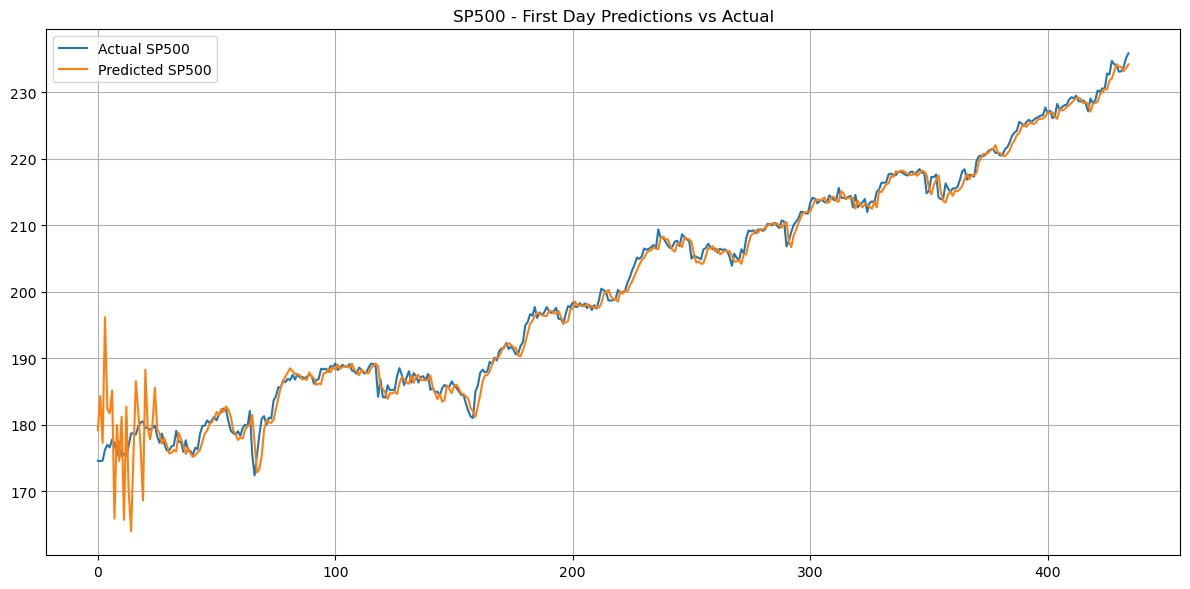

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get actual values for SP500 (column index for SP500)
sp500_col_idx = list(data.columns).index('SP500')

# Get predicted values for SP500 from all predictions
# predictions shape is (454, 14, 32) - samples, prediction length, features
predicted_sp500 = predictions[:, :, sp500_col_idx]

# The actual test data needs to be aligned with predictions
# We need to get the actual values that correspond to our prediction horizon
actual_sp500_values = []

# For each prediction starting point, collect the next 14 actual values
for i in range(len(predictions)):
    # Start from seq_len (where predictions begin) + i
    start_idx = args.seq_len + i
    if start_idx + args.pred_len <= len(test_data):
        actual_values = test_data.iloc[start_idx:start_idx+args.pred_len, sp500_col_idx].values
        actual_sp500_values.append(actual_values)

# Convert to numpy array
actual_sp500_array = np.array(actual_sp500_values)

# Make sure we're comparing same number of samples
min_samples = min(len(actual_sp500_array), len(predicted_sp500))
actual_sp500_array = actual_sp500_array[:min_samples]
predicted_sp500 = predicted_sp500[:min_samples]

# Calculate metrics for first day predictions
mae_first_day = mean_absolute_error(actual_sp500_array[:, 0], predicted_sp500[:, 0])

# Calculate metrics across all 14 days (flattened)
mae_all = mean_absolute_error(actual_sp500_array.flatten(), predicted_sp500.flatten())

# Inverse transform to get original scale values
# Create temporary arrays for inverse transformation
temp_actual = np.zeros((len(actual_sp500_array[:, 0]), len(data.columns)))
temp_actual[:, sp500_col_idx] = actual_sp500_array[:, 0]

temp_pred = np.zeros((len(predicted_sp500[:, 0]), len(data.columns)))
temp_pred[:, sp500_col_idx] = predicted_sp500[:, 0]

# Inverse transform
actual_original = scaler.inverse_transform(temp_actual)[:, sp500_col_idx]
predicted_original = scaler.inverse_transform(temp_pred)[:, sp500_col_idx]

# Print results
print(f"Scaled metrics (first day) - MAE: {mae_first_day:.4f}")
print(f"Scaled metrics (all days) - MAE: {mae_all:.4f}")

# Plot first day predictions 
plt.figure(figsize=(12, 6))
plt.plot(actual_original[5:], label='Actual SP500')
plt.plot(predicted_original[5:], label='Predicted SP500')
plt.title('SP500 - First Day Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy

def create_gradient_friendly_model(original_model, args):
    """
    Create a version of the SOFTS model that avoids in-place operations
    """
    from models.SOFTS import Model
    
    # Create new model instance
    new_model = Model(args).float()
    
    # Copy weights from original model
    new_model.load_state_dict(original_model.state_dict())
    
    # Patch the model to avoid in-place operations
    def safe_forecast(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        # Normalization from Transformer (avoid in-place ops)
        if self.use_norm:
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc_norm = x_enc - means  # Not in-place
            stdev = torch.sqrt(torch.var(x_enc_norm, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x_enc_norm = x_enc_norm / stdev  # Not in-place
        else:
            x_enc_norm = x_enc

        _, _, N = x_enc_norm.shape
        enc_out = self.enc_embedding(x_enc_norm, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=None)
        dec_out = self.projection(enc_out).permute(0, 2, 1)[:, :, :N]

        # De-Normalization from Transformer (avoid in-place ops)
        if self.use_norm:
            dec_out = dec_out * (stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
            dec_out = dec_out + (means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
        
        return dec_out

    # Replace the forecast method
    new_model.forecast = safe_forecast.__get__(new_model, Model)
    
    return new_model

def fgsm_attack_softs_working(model, batch_x, batch_y, batch_x_mark, epsilon=0.025):
    """
    FGSM attack on SOFTS
    """
    # Create gradient-friendly model
    attack_model = create_gradient_friendly_model(model, args)
    attack_model.train()
    
    # Move to same device as original model
    device = next(model.parameters()).device
    attack_model = attack_model.to(device)
    
    # Create input that requires gradients
    batch_x_adv = batch_x.clone().detach().requires_grad_(True)
    batch_x_mark_input = batch_x_mark.clone().detach()
    batch_y_target = batch_y.clone().detach()
    
    # Forward pass
    outputs = attack_model(batch_x_adv, batch_x_mark_input, None, None)
    
    # Extract predictions
    f_dim = -1 if args.features == 'MS' else 0
    predictions = outputs[:, -args.pred_len:, f_dim:]
    targets = batch_y_target[:, -args.pred_len:, f_dim:]
    
    # Calculate loss
    loss = torch.mean((predictions - targets) ** 2)
    
    # Get gradients
    gradients = torch.autograd.grad(
        outputs=loss,
        inputs=batch_x_adv,
        create_graph=False,
        retain_graph=False,
        only_inputs=True
    )[0]
    
    # Apply perturbation
    perturbation = epsilon * torch.sign(gradients)
    batch_x_adversarial = batch_x_adv.detach() + perturbation
    
    return batch_x_adversarial

def generate_softs_adversarial_working(model, test_data, epsilon=0.025, args=args):
    """
    Generate adversarial data
    """
    print(f"Generating adversarial examples with epsilon={epsilon}")
    
    # Prepare test dataset and dataloader
    test_dataset, test_loader = Exp._get_data(test_data, mode='test')
    
    # Initialize storage for results
    original_predictions = []
    adversarial_predictions = []
    original_inputs = []
    adversarial_inputs = []
    targets = []
    
    device = next(model.parameters()).device
    total_batches = len(test_loader)
    successful_attacks = 0
    
    for i, (batch_x, batch_y, batch_x_mark) in enumerate(test_loader):
        # Move to device
        batch_x = batch_x.float().to(device)
        batch_y = batch_y.float().to(device)
        batch_x_mark = batch_x_mark.float().to(device)
        
        # Generate original predictions
        model.eval()
        with torch.no_grad():
            original_outputs = model(batch_x, batch_x_mark, None, None)
            f_dim = -1 if args.features == 'MS' else 0
            original_preds = original_outputs[:, -args.pred_len:, f_dim:]
        
        # Generate adversarial inputs
        try:
            batch_x_adv = fgsm_attack_softs_working(model, batch_x, batch_y, batch_x_mark, epsilon)
            successful_attacks += 1
        except Exception as e:
            print(f"Attack failed for batch {i}: {e}")
            batch_x_adv = batch_x.clone()
        
        # Generate adversarial predictions
        model.eval()
        with torch.no_grad():
            adversarial_outputs = model(batch_x_adv, batch_x_mark, None, None)
            adversarial_preds = adversarial_outputs[:, -args.pred_len:, f_dim:]
        
        # Store results
        original_predictions.append(original_preds.cpu().numpy())
        adversarial_predictions.append(adversarial_preds.cpu().numpy())
        original_inputs.append(batch_x.cpu().numpy())
        adversarial_inputs.append(batch_x_adv.cpu().numpy())
        targets.append(batch_y[:, -args.pred_len:, f_dim:].cpu().numpy())
        
        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{total_batches} batches (successful attacks: {successful_attacks}/{i+1})")
    
    print(f"Total successful attacks: {successful_attacks}/{total_batches}")
    
    # Concatenate all results
    results = {
        'original_predictions': np.concatenate(original_predictions, axis=0),
        'adversarial_predictions': np.concatenate(adversarial_predictions, axis=0),
        'original_inputs': np.concatenate(original_inputs, axis=0),
        'adversarial_inputs': np.concatenate(adversarial_inputs, axis=0),
        'targets': np.concatenate(targets, axis=0)
    }
    
    # Calculate metrics
    original_mse = np.mean((results['original_predictions'] - results['targets']) ** 2)
    adversarial_mse = np.mean((results['adversarial_predictions'] - results['targets']) ** 2)
    
    # Calculate perturbation statistics
    input_perturbation = np.mean(np.abs(results['adversarial_inputs'] - results['original_inputs']))
    prediction_change = np.mean(np.abs(results['adversarial_predictions'] - results['original_predictions']))
    
    print(f"\n=== Adversarial Attack Results ===")
    print(f"Original MSE: {original_mse:.6f}")
    print(f"Adversarial MSE: {adversarial_mse:.6f}")
    print(f"MSE Increase: {adversarial_mse - original_mse:.6f} ({((adversarial_mse/original_mse - 1) * 100):.2f}%)")
    print(f"Average input perturbation: {input_perturbation:.6f}")
    print(f"Average prediction change: {prediction_change:.6f}")
    print(f"Attack success rate: {successful_attacks}/{total_batches} ({100*successful_attacks/total_batches:.1f}%)")
    
    return results


def plot_adversarial_comparison_scaled(results, stock_idx=0, sample_idx=0, stock_names=None):
    """
    Plot comparison between original and adversarial predictions (normalized scale only)
    
    Args:
        results: Results dictionary from generate_softs_adversarial_working
        stock_idx: Which stock to plot (0-31)
        sample_idx: Which sample to plot
        stock_names: List of stock names for labeling
    """
    if stock_names is None:
        stock_names = [f'Stock_{i}' for i in range(32)]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'FGSM Attack Results - {stock_names[stock_idx]}', fontsize=16)
    
    # Plot 1: Input sequences comparison (normalized scale)
    axes[0].plot(results['original_inputs'][sample_idx, :, stock_idx], 
                   label='Original Input', linewidth=2, color='blue')
    axes[0].plot(results['adversarial_inputs'][sample_idx, :, stock_idx], 
                   label='Adversarial Input', linewidth=2, alpha=0.8, color='red')
    axes[0].set_title('Input Sequences (Normalized)')
    axes[0].set_xlabel('Time Steps')
    axes[0].set_ylabel('Normalized Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Prediction difference (normalized scale)
    pred_diff = results['adversarial_predictions'][sample_idx, :, stock_idx] - results['original_predictions'][sample_idx, :, stock_idx]
    axes[1].plot(pred_diff, color='orange', linewidth=2)
    axes[1].set_title('Prediction Difference (Normalized Scale)')
    axes[1].set_xlabel('Prediction Steps')
    axes[1].set_ylabel('Prediction Change')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics for this sample (normalized scale)
    perturbation = results['adversarial_inputs'][sample_idx, :, stock_idx] - results['original_inputs'][sample_idx, :, stock_idx]
    
    print(f"\n=== Statistics for {stock_names[stock_idx]} (Normalized Scale) ===")
    print(f"Min input perturbation: {np.min(perturbation):.6f}")
    print(f"Max input perturbation: {np.max(np.abs(perturbation)):.6f}")
    print(f"Average prediction change: {np.mean(np.abs(pred_diff)):.6f}")
    print(f"Max prediction change: {np.max(np.abs(pred_diff)):.6f}")
    
    # Calculate prediction accuracy metrics
    orig_mae = np.mean(np.abs(results['targets'][sample_idx, :, stock_idx] - results['original_predictions'][sample_idx, :, stock_idx]))
    adv_mae = np.mean(np.abs(results['targets'][sample_idx, :, stock_idx] - results['adversarial_predictions'][sample_idx, :, stock_idx]))
    print(f"Original prediction MAE: {orig_mae:.6f}")
    print(f"Adversarial prediction MAE: {adv_mae:.6f}")
    print(f"MAE increase: {((adv_mae/orig_mae - 1) * 100):.2f}%")

def analyze_attack_effectiveness_scaled(results, stock_names=None):
    """
    Analyze the effectiveness of the adversarial attack across all stocks
    """
    if stock_names is None:
        stock_names = [f'Stock_{i}' for i in range(32)]
    
    n_stocks = results['original_predictions'].shape[2]
    
    # Calculate MSE for each stock (in normalized space)
    original_mse_per_stock = []
    adversarial_mse_per_stock = []
    
    for stock_idx in range(n_stocks):
        orig_mse = np.mean((results['original_predictions'][:, :, stock_idx] - 
                           results['targets'][:, :, stock_idx]) ** 2)
        adv_mse = np.mean((results['adversarial_predictions'][:, :, stock_idx] - 
                          results['targets'][:, :, stock_idx]) ** 2)
        
        original_mse_per_stock.append(orig_mse)
        adversarial_mse_per_stock.append(adv_mse)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # MSE comparison
    x = np.arange(n_stocks)
    width = 0.35
    
    ax1.bar(x - width/2, original_mse_per_stock, width, label='Original', alpha=0.8, color='blue')
    ax1.bar(x + width/2, adversarial_mse_per_stock, width, label='Adversarial', alpha=0.8, color='red')
    ax1.set_xlabel('Stock Index')
    ax1.set_ylabel('MSE (Normalized Scale)')
    ax1.set_title('MSE Comparison by Stock')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # MSE increase percentage
    mse_increase_pct = [(adv/orig - 1) * 100 for orig, adv in zip(original_mse_per_stock, adversarial_mse_per_stock)]
    ax2.bar(x, mse_increase_pct, alpha=0.8, color='orange')
    ax2.set_xlabel('Stock Index')
    ax2.set_ylabel('MSE Increase (%)')
    ax2.set_title('MSE Increase Percentage by Stock')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== Attack Effectiveness Summary ===")
    print(f"Average MSE increase: {np.mean(mse_increase_pct):.2f}%")
    print(f"Max MSE increase: {np.max(mse_increase_pct):.2f}%")
    print(f"Min MSE increase: {np.min(mse_increase_pct):.2f}%")


Running WORKING FGSM attack with epsilon = 0.05
Generating adversarial examples with epsilon=0.05
Processed 10/28 batches (successful attacks: 10/10)
Processed 20/28 batches (successful attacks: 20/20)
Total successful attacks: 28/28

=== Adversarial Attack Results ===
Original MSE: 0.223338
Adversarial MSE: 0.253753
MSE Increase: 0.030415 (13.62%)
Average input perturbation: 0.050000
Average prediction change: 0.066888
Attack success rate: 28/28 (100.0%)

Plotting results for epsilon = 0.05


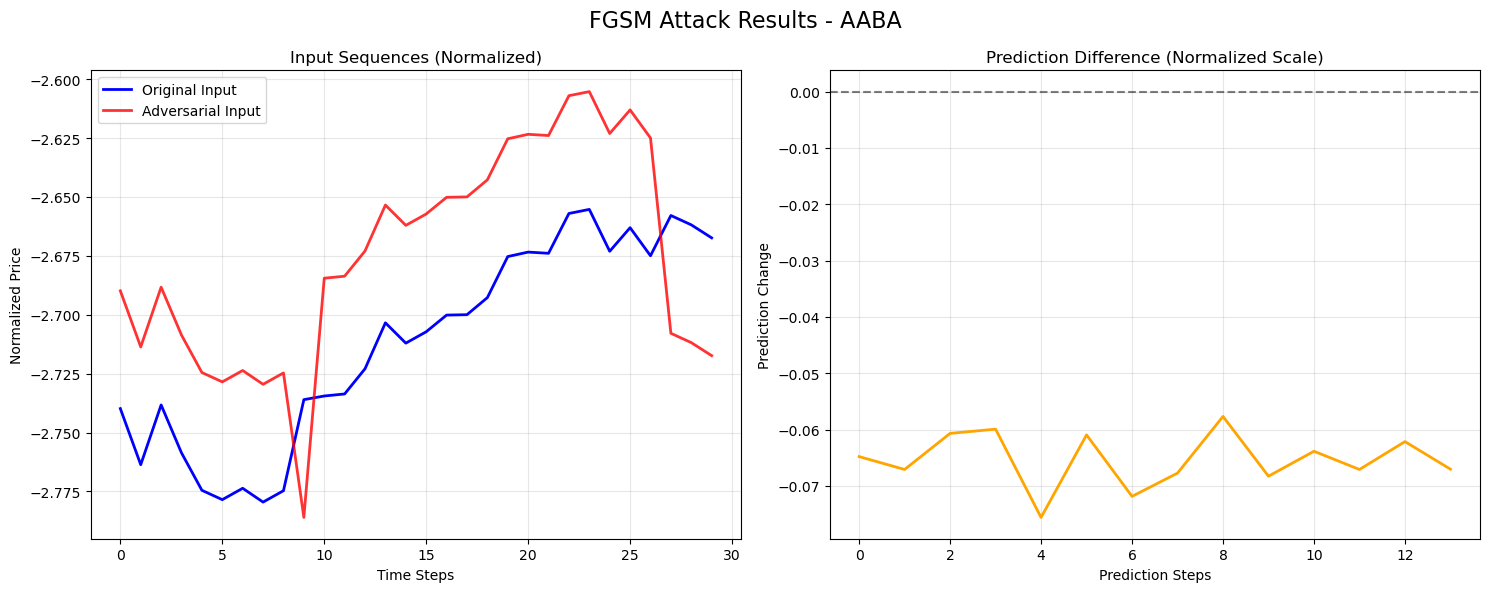


=== Statistics for AABA (Normalized Scale) ===
Min input perturbation: -0.050000
Max input perturbation: 0.050000
Average prediction change: 0.065323
Max prediction change: 0.075587
Original prediction MAE: 4.482593
Adversarial prediction MAE: 4.547916
MAE increase: 1.46%


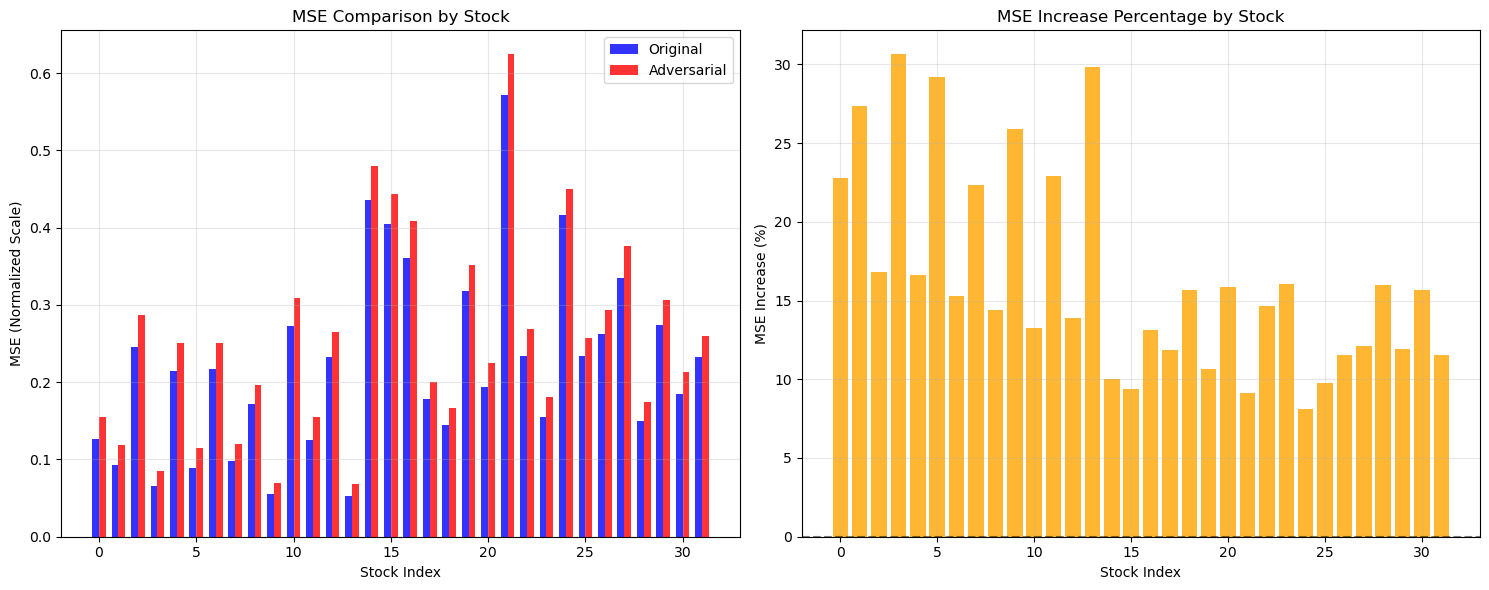


=== Attack Effectiveness Summary ===
Average MSE increase: 16.38%
Max MSE increase: 30.63%
Min MSE increase: 8.11%


In [49]:

# Generate adversarial examples with different epsilon values
epsilons = [0.05]
results_dict = {}

for epsilon in epsilons:
    print(f"\n{'='*50}")
    print(f"Running WORKING FGSM attack with epsilon = {epsilon}")
    print(f"{'='*50}")
    
    results = generate_softs_adversarial_working(
        model=Exp.model,
        test_data=test_data,
        epsilon=epsilon,
        args=args
    )
    
    results_dict[epsilon] = results

# Plot comparison for the first epsilon with normalized scale only
epsilon_to_plot = epsilons[0]
stock_names = list(data.columns)  # Use actual stock names from the data

print(f"\nPlotting results for epsilon = {epsilon_to_plot}")

# Plot with normalized scale
plot_adversarial_comparison_scaled(
    results_dict[epsilon_to_plot], 
    stock_idx=0,  # Plot first stock (AABA)
    sample_idx=0, 
    stock_names=stock_names
)

# Analyze attack effectiveness (normalized scale)
analyze_attack_effectiveness_scaled(
    results_dict[epsilon_to_plot], 
    stock_names=stock_names
)


Metrics for SP500 (Sample 30):
Original Prediction MAE: 0.1085
Adversarial Prediction MAE: 0.1603
Average Prediction Difference: 0.0519
Adversarial Impact: 47.80% change in error
Prediction Period: 2016-04-28 to 2016-05-17


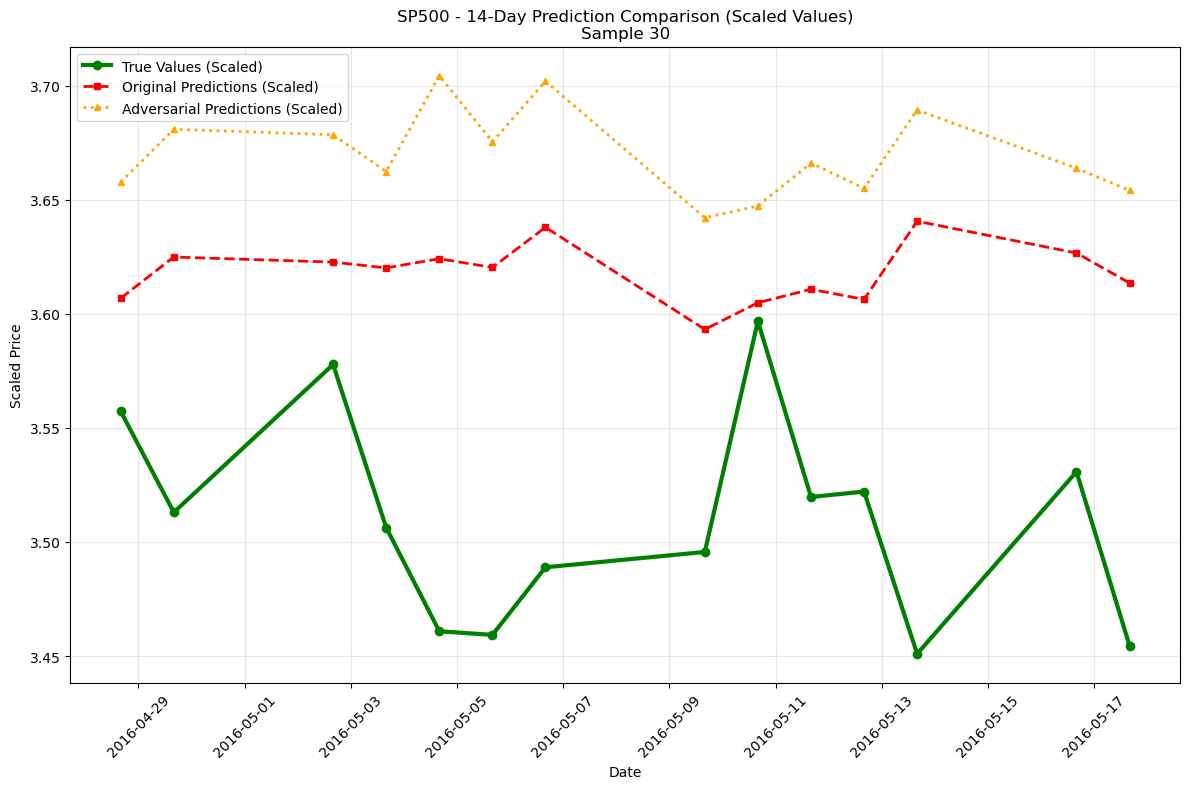


Metrics for AAPL (Sample 30):
Original Prediction MAE: 0.2718
Adversarial Prediction MAE: 0.3405
Average Prediction Difference: 0.0686
Adversarial Impact: 25.25% change in error
Prediction Period: 2016-04-28 to 2016-05-17


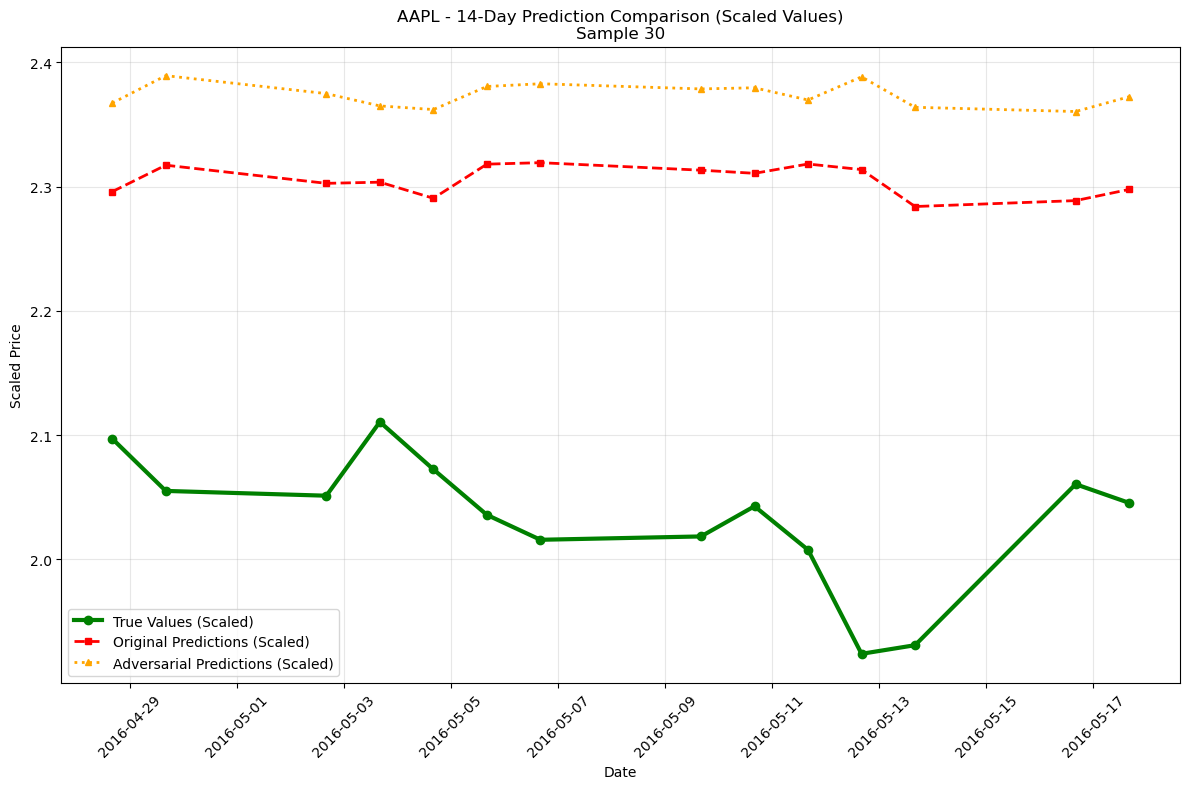

In [50]:
# Cell: Plot Stock Predictions with Real Dates

def plot_stock_predictions_with_dates(original_preds, adversarial_preds, test_data, stock_idx=None, stock_name=None, 
                                    sample_idx=30):
    """
    Plot actual stock price, original prediction, and adversarial prediction with real dates
    (Prediction period only - 14 days)
    
    Args:
        original_preds: Original model predictions
        adversarial_preds: Adversarial model predictions  
        test_data: Test dataset (scaled)
        stock_idx: Index of stock to plot (default is SP500)
        stock_name: Name of stock for title
        sample_idx: Which sample sequence to plot
    """
    import pandas as pd
    from datetime import datetime, timedelta
    
    # Default to SP500 if not specified
    if stock_idx is None:
        stock_idx = list(test_data.columns).index('SP500')
        stock_name = 'SP500'
    
    # Load original data to get dates
    original_data = pd.read_csv('../data/processed/softs_cleaned_data.csv')
    original_data['date'] = pd.to_datetime(original_data['date'])
    
    # Calculate the date range for this sample
    # Test data starts at val_end - seq_len in the original split
    N = len(original_data)
    val_end = int(N * 0.85)
    test_start_in_original = val_end - args.seq_len
    
    # The prediction starts at test_start + seq_len + sample_idx
    prediction_start_idx = test_start_in_original + args.seq_len + sample_idx
    prediction_end_idx = prediction_start_idx + args.pred_len
    
    # Ensure we don't exceed available data
    if prediction_end_idx > len(original_data):
        print(f"Warning: Not enough data for sample {sample_idx}")
        return
    
    # Extract dates for prediction period only
    pred_dates = original_data['date'].iloc[prediction_start_idx:prediction_end_idx]
    
    # Get scaled actual values for prediction period
    pred_actual = test_data.iloc[args.seq_len + sample_idx:args.seq_len + sample_idx + args.pred_len, stock_idx].values
    
    # Get predictions (already scaled)
    original_pred = original_preds[sample_idx, :, stock_idx]
    adversarial_pred = adversarial_preds[sample_idx, :, stock_idx]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Plot prediction period only
    plt.plot(pred_dates, pred_actual, 'g-', linewidth=3, label='True Values (Scaled)', marker='o', markersize=6)
    plt.plot(pred_dates, original_pred, 'r--', linewidth=2, label='Original Predictions (Scaled)', marker='s', markersize=5)
    plt.plot(pred_dates, adversarial_pred, 'orange', linestyle=':', linewidth=2, 
             label='Adversarial Predictions (Scaled)', marker='^', markersize=5)
    
    # Formatting
    plt.title(f'{stock_name} - 14-Day Prediction Comparison (Scaled Values)\nSample {sample_idx}')
    plt.xlabel('Date')
    plt.ylabel('Scaled Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Calculate and display metrics
    orig_mae = np.mean(np.abs(pred_actual - original_pred))
    adv_mae = np.mean(np.abs(pred_actual - adversarial_pred))
    pred_diff = np.mean(np.abs(original_pred - adversarial_pred))
    
    print(f"\nMetrics for {stock_name} (Sample {sample_idx}):")
    print(f"Original Prediction MAE: {orig_mae:.4f}")
    print(f"Adversarial Prediction MAE: {adv_mae:.4f}")
    print(f"Average Prediction Difference: {pred_diff:.4f}")
    print(f"Adversarial Impact: {((adv_mae - orig_mae) / orig_mae * 100):.2f}% change in error")
    
    # Show date range
    print(f"Prediction Period: {pred_dates.iloc[0].strftime('%Y-%m-%d')} to {pred_dates.iloc[-1].strftime('%Y-%m-%d')}")
    
    plt.show()

# Example usage - plot SP500 predictions only
plot_stock_predictions_with_dates(
    original_preds=results_dict[0.05]['original_predictions'],  # Replace with your results
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],  # Replace with your results
    test_data=test_data,
    stock_name='SP500',
    sample_idx=30
)

# Plot other stocks
# AAPL example
aapl_idx = list(test_data.columns).index('AAPL')
plot_stock_predictions_with_dates(
    original_preds=results_dict[0.05]['original_predictions'],
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],
    test_data=test_data,
    stock_idx=aapl_idx,
    stock_name='AAPL',
    sample_idx=30
)

# You can also create a function to plot multiple stocks at once
def plot_multiple_stocks_predictions(original_preds, adversarial_preds, test_data, stock_names, sample_idx=30):
    """Plot predictions for multiple stocks in subplots"""
    n_stocks = len(stock_names)
    fig, axes = plt.subplots(n_stocks, 1, figsize=(12, 4*n_stocks))
    if n_stocks == 1:
        axes = [axes]
    
    for i, stock_name in enumerate(stock_names):
        stock_idx = list(test_data.columns).index(stock_name)
        
        # Get data
        original_data = pd.read_csv('../data/processed/softs_cleaned_data.csv')
        original_data['date'] = pd.to_datetime(original_data['date'])
        
        N = len(original_data)
        val_end = int(N * 0.85)
        test_start_in_original = val_end - args.seq_len
        prediction_start_idx = test_start_in_original + args.seq_len + sample_idx


Metrics for SP500 (Sample 30):
Original Prediction MAE: 0.1085
Adversarial Prediction MAE: 0.1569
Average Prediction Difference: 0.0485
Average Input Perturbation: 0.0500
Adversarial Impact: 44.66% change in error
Input Period: 2016-03-16 to 2016-04-27
Prediction Period: 2016-04-28 to 2016-05-17


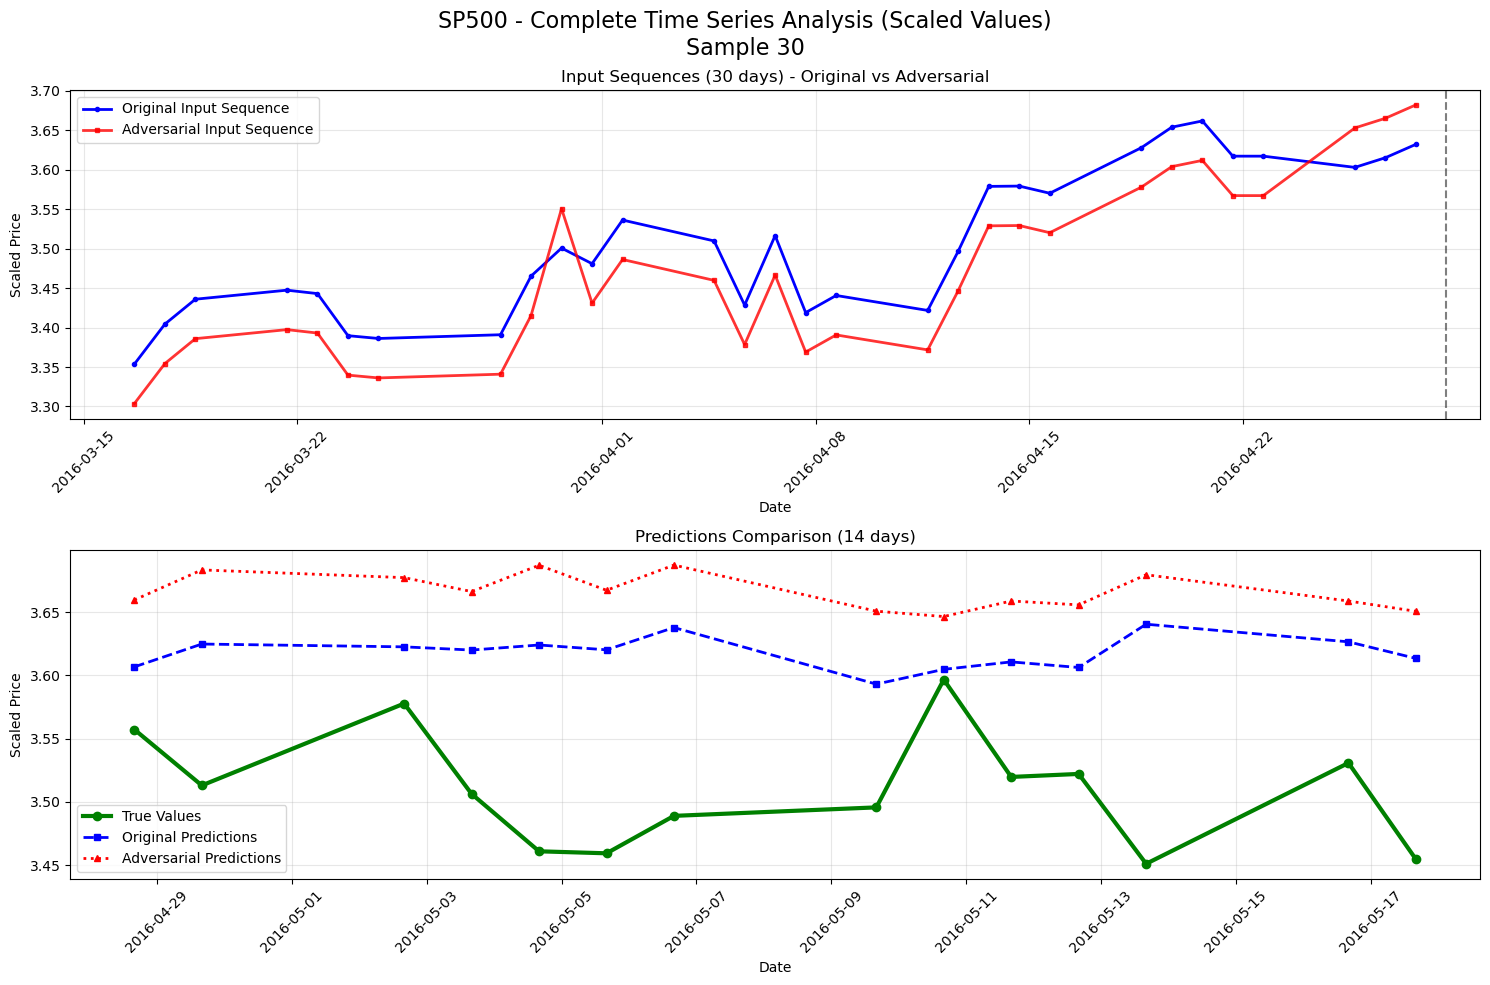

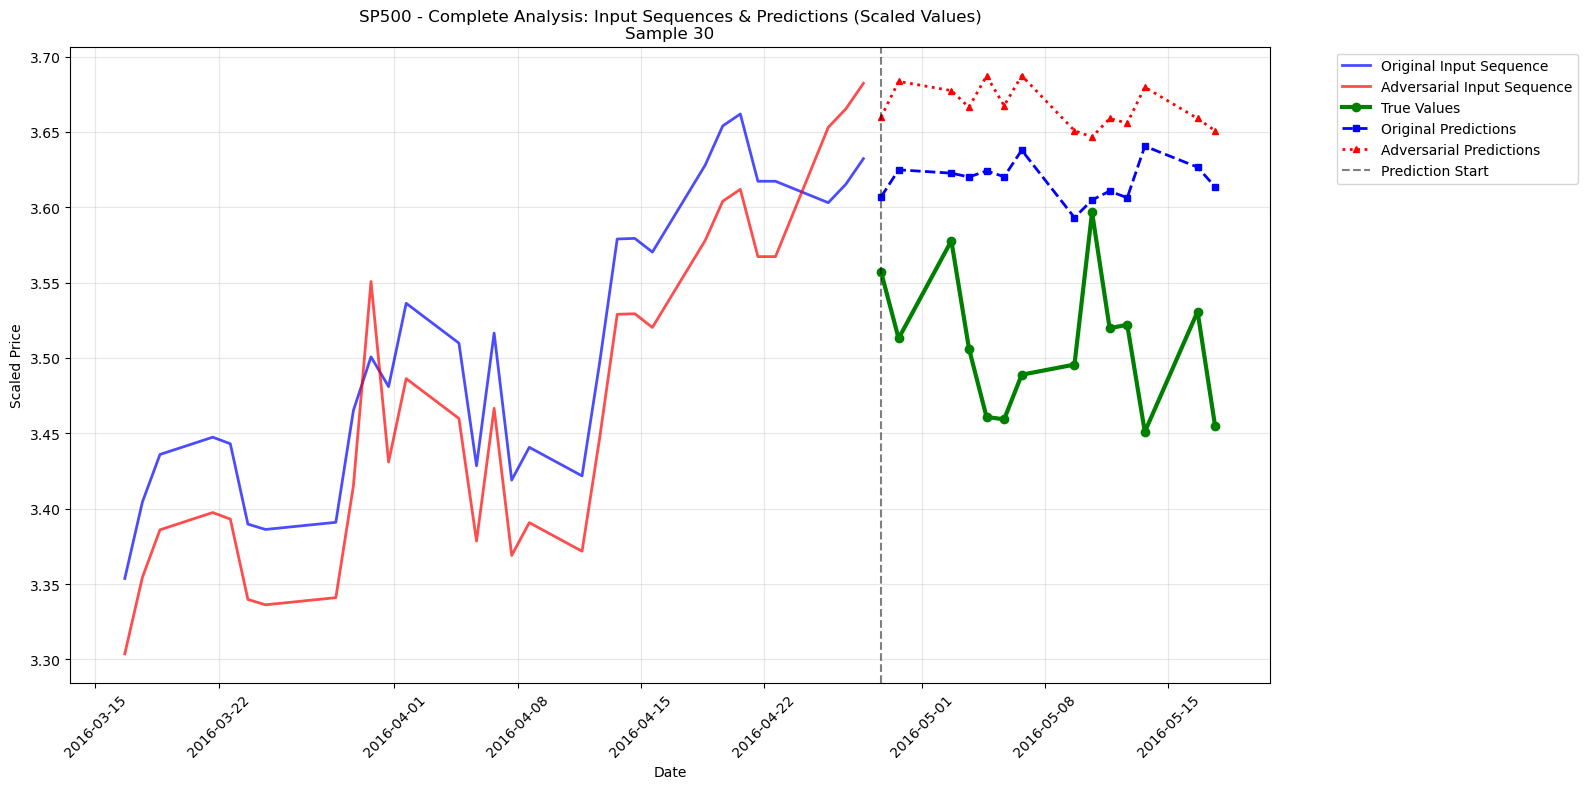


Metrics for AAPL (Sample 30):
Original Prediction MAE: 0.2718
Adversarial Prediction MAE: 0.3405
Average Prediction Difference: 0.0687
Average Input Perturbation: 0.0500
Adversarial Impact: 25.26% change in error
Input Period: 2016-03-16 to 2016-04-27
Prediction Period: 2016-04-28 to 2016-05-17


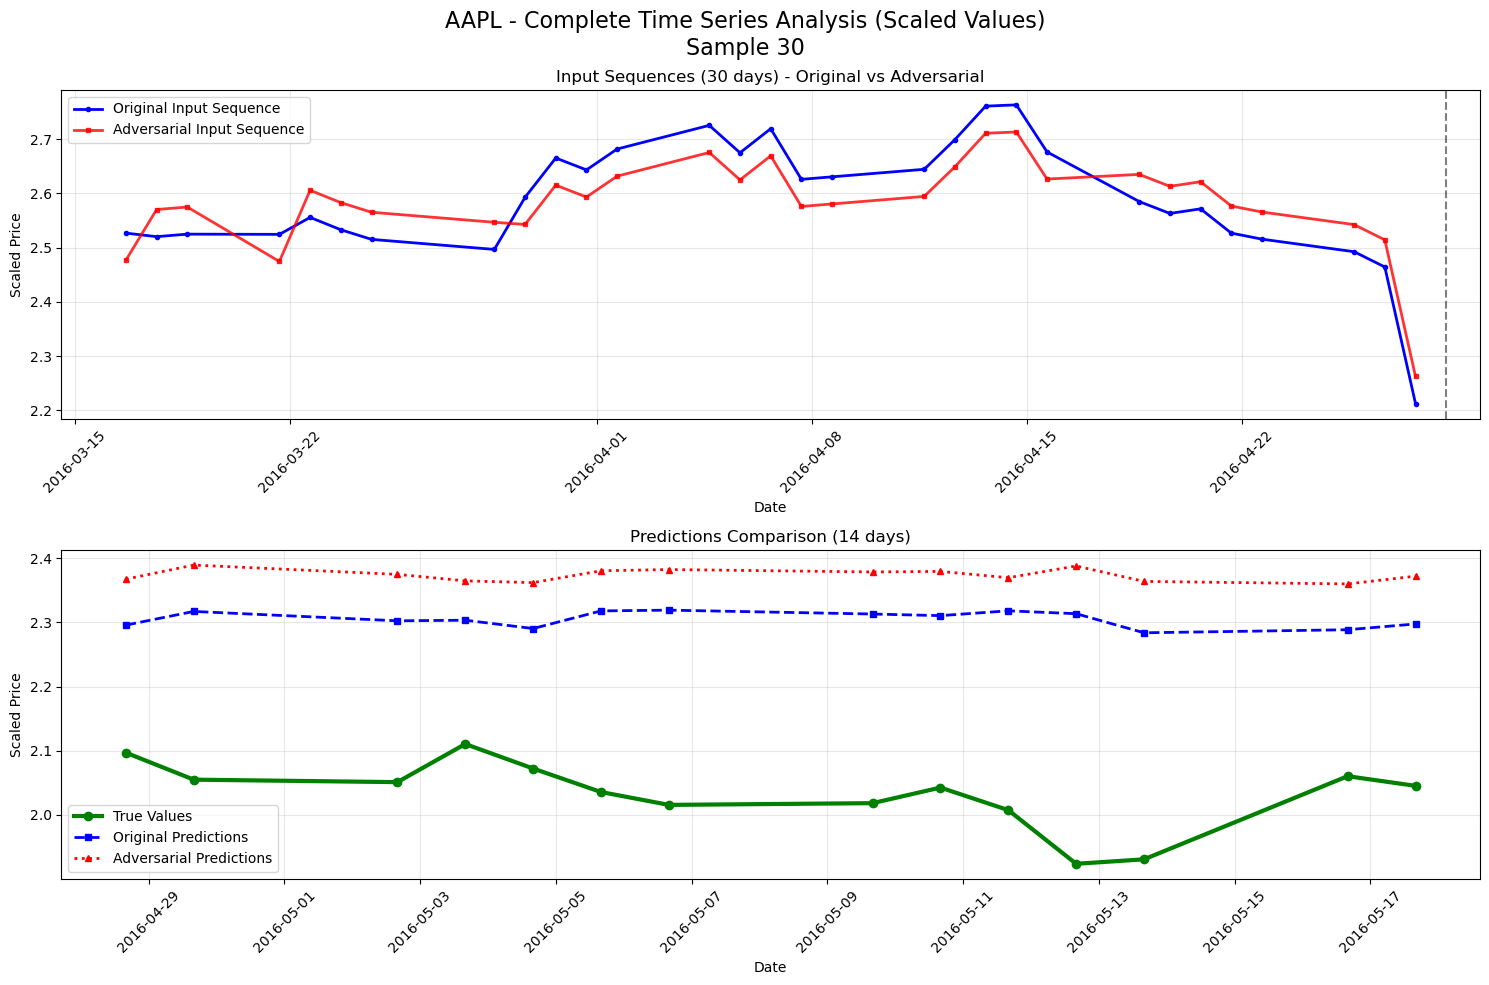

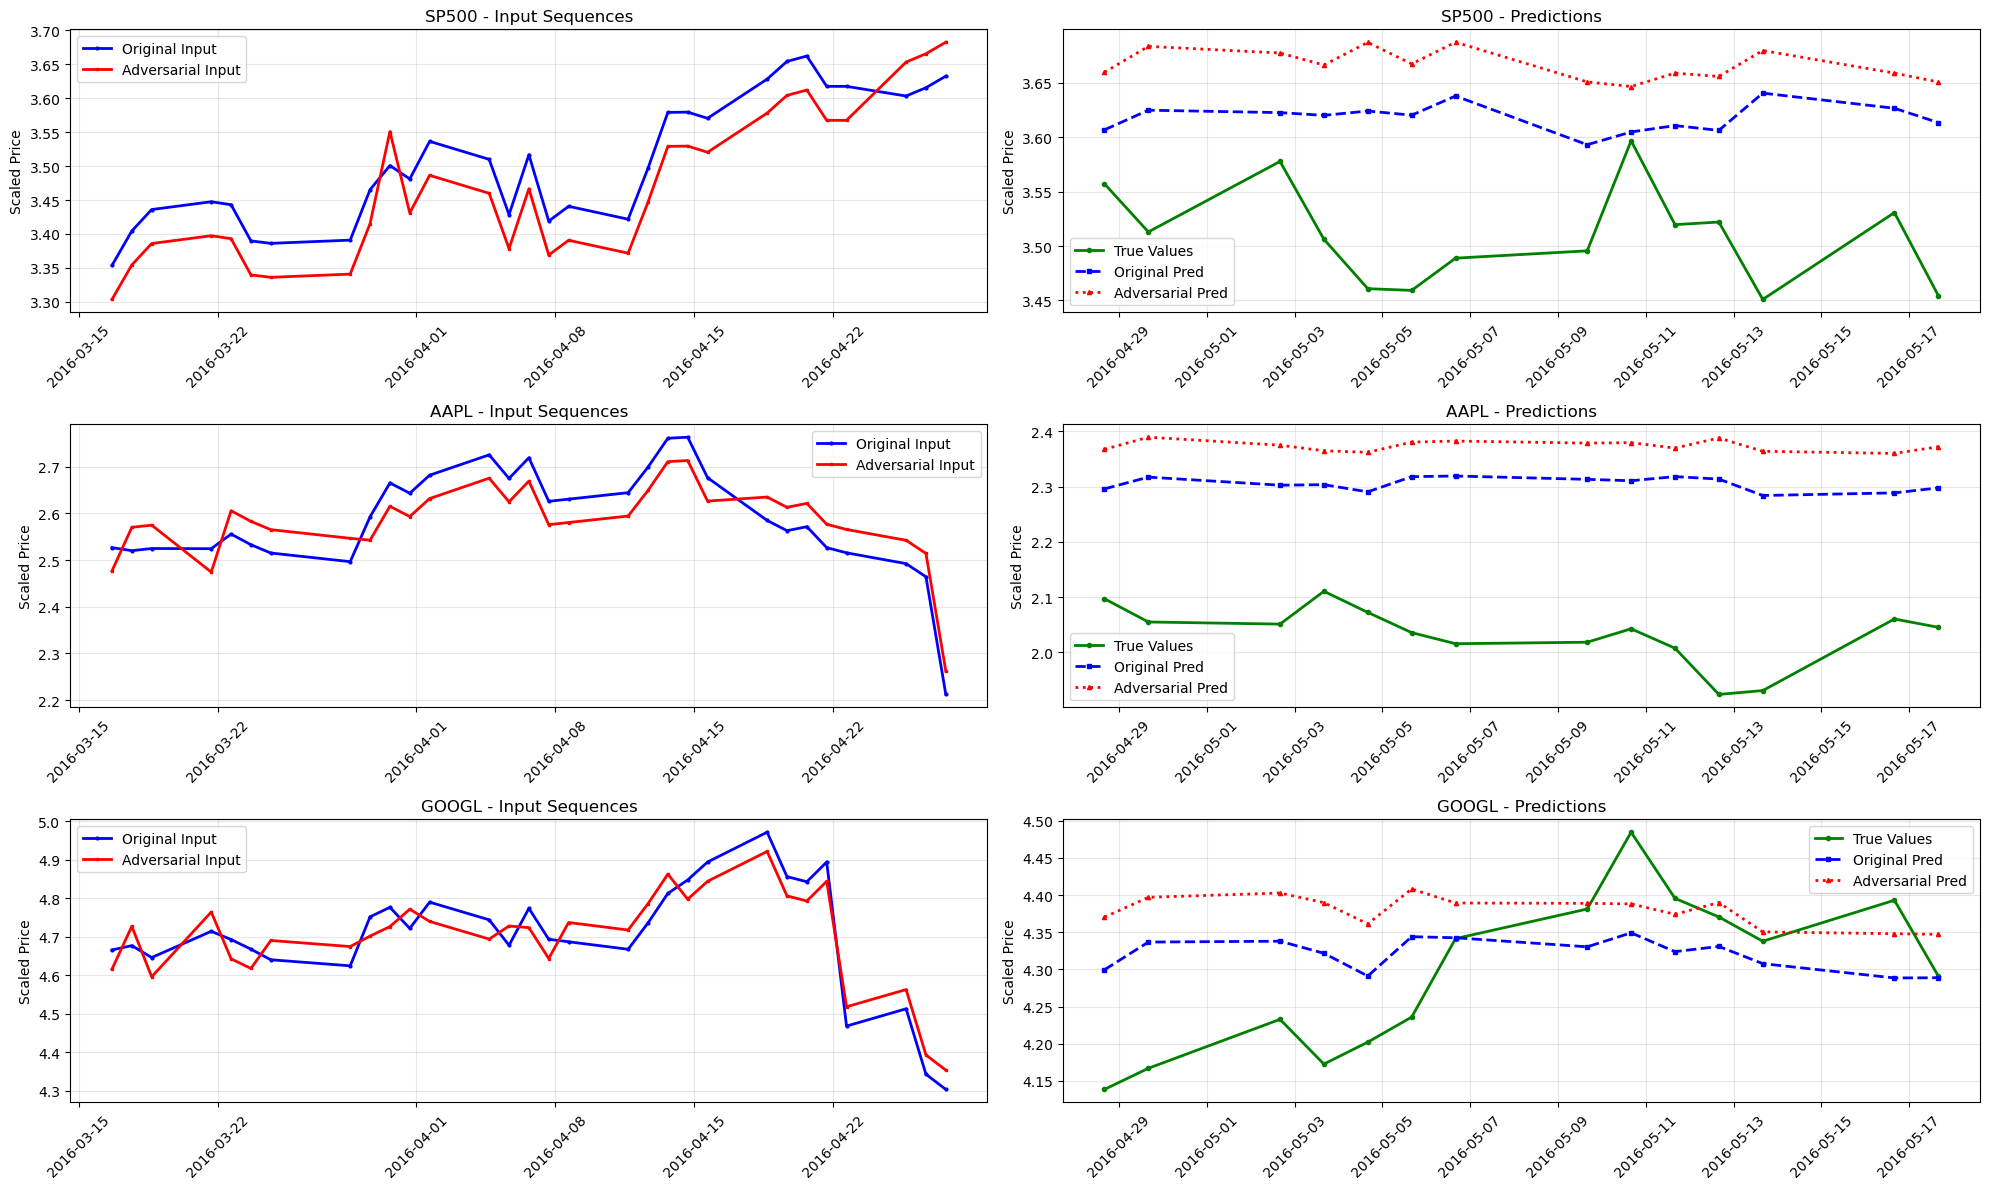

In [42]:
# Cell: Plot Stock Predictions with Real Dates (Prediction Period Only)

def plot_stock_predictions_with_dates(original_preds, adversarial_preds, test_data, adversarial_inputs, stock_idx=None, stock_name=None, 
                                    sample_idx=30):
    """
    Plot actual stock price, original prediction, adversarial prediction, and adversarial time series with real dates
    (Prediction period only - 14 days)
    
    Args:
        original_preds: Original model predictions
        adversarial_preds: Adversarial model predictions  
        test_data: Test dataset (scaled)
        adversarial_inputs: Adversarial input sequences
        stock_idx: Index of stock to plot (default is SP500)
        stock_name: Name of stock for title
        sample_idx: Which sample sequence to plot
    """
    import pandas as pd
    from datetime import datetime, timedelta
    
    # Default to SP500 if not specified
    if stock_idx is None:
        stock_idx = list(test_data.columns).index('SP500')
        stock_name = 'SP500'
    
    # Load original data to get dates
    original_data = pd.read_csv('../data/processed/softs_cleaned_data.csv')
    original_data['date'] = pd.to_datetime(original_data['date'])
    
    # Calculate the date range for this sample
    # Test data starts at val_end - seq_len in the original split
    N = len(original_data)
    val_end = int(N * 0.85)
    test_start_in_original = val_end - args.seq_len
    
    # The prediction starts at test_start + seq_len + sample_idx
    prediction_start_idx = test_start_in_original + args.seq_len + sample_idx
    prediction_end_idx = prediction_start_idx + args.pred_len
    
    # Ensure we don't exceed available data
    if prediction_end_idx > len(original_data):
        print(f"Warning: Not enough data for sample {sample_idx}")
        return
    
    # Extract dates for input and prediction periods
    input_start_idx = prediction_start_idx - args.seq_len
    input_dates = original_data['date'].iloc[input_start_idx:prediction_start_idx]
    pred_dates = original_data['date'].iloc[prediction_start_idx:prediction_end_idx]
    
    # Get scaled actual values
    input_actual = test_data.iloc[sample_idx:sample_idx+args.seq_len, stock_idx].values
    pred_actual = test_data.iloc[args.seq_len + sample_idx:args.seq_len + sample_idx + args.pred_len, stock_idx].values
    
    # Get adversarial input sequence (scaled)
    adversarial_input_seq = adversarial_inputs[sample_idx, :, stock_idx]
    
    # Get predictions (already scaled)
    original_pred = original_preds[sample_idx, :, stock_idx]
    adversarial_pred = adversarial_preds[sample_idx, :, stock_idx]
    
    # Create the plot with subplots for better visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    fig.suptitle(f'{stock_name} - Complete Time Series Analysis (Scaled Values)\nSample {sample_idx}', fontsize=16)
    
    # Plot 1: Input sequences (original vs adversarial)
    ax1.plot(input_dates, input_actual, 'b-', linewidth=2, label='Original Input Sequence', marker='o', markersize=3)
    ax1.plot(input_dates, adversarial_input_seq, 'r-', linewidth=2, label='Adversarial Input Sequence', marker='s', markersize=3, alpha=0.8)
    ax1.set_title('Input Sequences (30 days) - Original vs Adversarial')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Scaled Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Add vertical line to show where predictions start
    ax1.axvline(x=pred_dates.iloc[0], color='black', linestyle='--', alpha=0.5, label='Prediction Start')
    
    # Plot 2: Predictions comparison
    ax2.plot(pred_dates, pred_actual, 'g-', linewidth=3, label='True Values', marker='o', markersize=6)
    ax2.plot(pred_dates, original_pred, 'b--', linewidth=2, label='Original Predictions', marker='s', markersize=5)
    ax2.plot(pred_dates, adversarial_pred, 'r:', linewidth=2, 
             label='Adversarial Predictions', marker='^', markersize=5)
    ax2.set_title('Predictions Comparison (14 days)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Scaled Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    # Calculate and display metrics
    orig_mae = np.mean(np.abs(pred_actual - original_pred))
    adv_mae = np.mean(np.abs(pred_actual - adversarial_pred))
    pred_diff = np.mean(np.abs(original_pred - adversarial_pred))
    input_perturbation = np.mean(np.abs(adversarial_input_seq - input_actual))
    
    print(f"\nMetrics for {stock_name} (Sample {sample_idx}):")
    print(f"Original Prediction MAE: {orig_mae:.4f}")
    print(f"Adversarial Prediction MAE: {adv_mae:.4f}")
    print(f"Average Prediction Difference: {pred_diff:.4f}")
    print(f"Average Input Perturbation: {input_perturbation:.4f}")
    print(f"Adversarial Impact: {((adv_mae - orig_mae) / orig_mae * 100):.2f}% change in error")
    
    # Show date range
    print(f"Input Period: {input_dates.iloc[0].strftime('%Y-%m-%d')} to {input_dates.iloc[-1].strftime('%Y-%m-%d')}")
    print(f"Prediction Period: {pred_dates.iloc[0].strftime('%Y-%m-%d')} to {pred_dates.iloc[-1].strftime('%Y-%m-%d')}")
    
    plt.show()

# Single plot version (all in one plot)
def plot_stock_predictions_single_plot(original_preds, adversarial_preds, test_data, adversarial_inputs, stock_idx=None, stock_name=None, 
                                     sample_idx=30):
    """
    Plot everything in a single plot for compact visualization
    """
    import pandas as pd
    from datetime import datetime, timedelta
    
    # Default to SP500 if not specified
    if stock_idx is None:
        stock_idx = list(test_data.columns).index('SP500')
        stock_name = 'SP500'
    
    # Load original data to get dates
    original_data = pd.read_csv('../data/processed/softs_cleaned_data.csv')
    original_data['date'] = pd.to_datetime(original_data['date'])
    
    # Calculate the date range for this sample
    N = len(original_data)
    val_end = int(N * 0.85)
    test_start_in_original = val_end - args.seq_len
    
    prediction_start_idx = test_start_in_original + args.seq_len + sample_idx
    prediction_end_idx = prediction_start_idx + args.pred_len
    
    if prediction_end_idx > len(original_data):
        print(f"Warning: Not enough data for sample {sample_idx}")
        return
    
    # Extract dates
    input_start_idx = prediction_start_idx - args.seq_len
    input_dates = original_data['date'].iloc[input_start_idx:prediction_start_idx]
    pred_dates = original_data['date'].iloc[prediction_start_idx:prediction_end_idx]
    
    # Get data
    input_actual = test_data.iloc[sample_idx:sample_idx+args.seq_len, stock_idx].values
    pred_actual = test_data.iloc[args.seq_len + sample_idx:args.seq_len + sample_idx + args.pred_len, stock_idx].values
    adversarial_input_seq = adversarial_inputs[sample_idx, :, stock_idx]
    original_pred = original_preds[sample_idx, :, stock_idx]
    adversarial_pred = adversarial_preds[sample_idx, :, stock_idx]
    
    # Create the plot
    plt.figure(figsize=(16, 8))
    
    # Plot input sequences
    plt.plot(input_dates, input_actual, 'b-', linewidth=2, label='Original Input Sequence', alpha=0.7)
    plt.plot(input_dates, adversarial_input_seq, 'r-', linewidth=2, label='Adversarial Input Sequence', alpha=0.7)
    
    # Plot predictions
    plt.plot(pred_dates, pred_actual, 'g-', linewidth=3, label='True Values', marker='o', markersize=6)
    plt.plot(pred_dates, original_pred, 'b--', linewidth=2, label='Original Predictions', marker='s', markersize=5)
    plt.plot(pred_dates, adversarial_pred, 'r:', linewidth=2, 
             label='Adversarial Predictions', marker='^', markersize=5)
    
    # Add vertical line to separate input from predictions
    plt.axvline(x=pred_dates.iloc[0], color='black', linestyle='--', alpha=0.5, label='Prediction Start')
    
    # Formatting
    plt.title(f'{stock_name} - Complete Analysis: Input Sequences & Predictions (Scaled Values)\nSample {sample_idx}')
    plt.xlabel('Date')
    plt.ylabel('Scaled Price')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage with adversarial inputs included
plot_stock_predictions_with_dates(
    original_preds=results_dict[0.05]['original_predictions'],
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],
    test_data=test_data,
    adversarial_inputs=results_dict[0.05]['adversarial_inputs'],  # Added this parameter
    stock_name='SP500',
    sample_idx=30
)

# Single plot version
plot_stock_predictions_single_plot(
    original_preds=results_dict[0.05]['original_predictions'],
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],
    test_data=test_data,
    adversarial_inputs=results_dict[0.05]['adversarial_inputs'],
    stock_name='SP500',
    sample_idx=30
)

# Plot other stocks
# AAPL example
aapl_idx = list(test_data.columns).index('AAPL')
plot_stock_predictions_with_dates(
    original_preds=results_dict[0.05]['original_predictions'],
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],
    test_data=test_data,
    adversarial_inputs=results_dict[0.05]['adversarial_inputs'],
    stock_idx=aapl_idx,
    stock_name='AAPL',
    sample_idx=30
)

# Updated multiple stocks function
def plot_multiple_stocks_predictions(original_preds, adversarial_preds, test_data, adversarial_inputs, stock_names, sample_idx=30):
    """Plot predictions for multiple stocks in subplots with adversarial inputs"""
    n_stocks = len(stock_names)
    fig, axes = plt.subplots(n_stocks, 2, figsize=(20, 4*n_stocks))
    if n_stocks == 1:
        axes = axes.reshape(1, -1)
    
    for i, stock_name in enumerate(stock_names):
        stock_idx = list(test_data.columns).index(stock_name)
        
        # Get data
        original_data = pd.read_csv('../data/processed/softs_cleaned_data.csv')
        original_data['date'] = pd.to_datetime(original_data['date'])
        
        N = len(original_data)
        val_end = int(N * 0.85)
        test_start_in_original = val_end - args.seq_len
        prediction_start_idx = test_start_in_original + args.seq_len + sample_idx
        prediction_end_idx = prediction_start_idx + args.pred_len
        
        input_start_idx = prediction_start_idx - args.seq_len
        input_dates = original_data['date'].iloc[input_start_idx:prediction_start_idx]
        pred_dates = original_data['date'].iloc[prediction_start_idx:prediction_end_idx]
        
        input_actual = test_data.iloc[sample_idx:sample_idx+args.seq_len, stock_idx].values
        pred_actual = test_data.iloc[args.seq_len + sample_idx:args.seq_len + sample_idx + args.pred_len, stock_idx].values
        adversarial_input_seq = adversarial_inputs[sample_idx, :, stock_idx]
        original_pred = original_preds[sample_idx, :, stock_idx]
        adversarial_pred = adversarial_preds[sample_idx, :, stock_idx]
        
        # Plot input sequences
        axes[i, 0].plot(input_dates, input_actual, 'b-', linewidth=2, label='Original Input', marker='o', markersize=2)
        axes[i, 0].plot(input_dates, adversarial_input_seq, 'r-', linewidth=2, label='Adversarial Input', marker='s', markersize=2)
        axes[i, 0].set_title(f'{stock_name} - Input Sequences')
        axes[i, 0].set_ylabel('Scaled Price')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        # Plot predictions
        axes[i, 1].plot(pred_dates, pred_actual, 'g-', linewidth=2, label='True Values', marker='o', markersize=3)
        axes[i, 1].plot(pred_dates, original_pred, 'b--', linewidth=2, label='Original Pred', marker='s', markersize=3)
        axes[i, 1].plot(pred_dates, adversarial_pred, 'r:', linewidth=2, 
                       label='Adversarial Pred', marker='^', markersize=3)
        axes[i, 1].set_title(f'{stock_name} - Predictions')
        axes[i, 1].set_ylabel('Scaled Price')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Example: Plot multiple stocks with adversarial inputs
plot_multiple_stocks_predictions(
    original_preds=results_dict[0.05]['original_predictions'],
    adversarial_preds=results_dict[0.05]['adversarial_predictions'],
    test_data=test_data,
    adversarial_inputs=results_dict[0.05]['adversarial_inputs'],
    stock_names=['SP500', 'AAPL', 'GOOGL'],
    sample_idx=30
)